In [12]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

load_dotenv()

model = ChatGroq(model='llama-3.1-8b-instant')

In [13]:
class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str

In [14]:
def generate_joke(state: JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = model.invoke(prompt).content

    return {'joke': response}

def generate_explanation(state: JokeState):

    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = model.invoke(prompt).content

    return {'explanation': response}

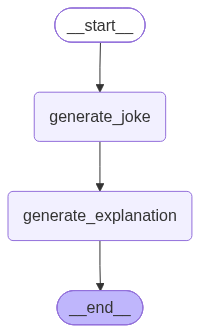

In [15]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

workflow

In [16]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'pizza'}, config=config1)

{'topic': 'pizza',
 'joke': 'Why was the pizza in a bad mood? \n\nBecause it was feeling a little crusty.',
 'explanation': 'The joke relies on a play on words between the phrase "feeling a little crusty" and the literal crust of a pizza. \n\nWhen people say they\'re "feeling a little crusty," it\'s an idiomatic expression that describes someone as being in a grumpy or irritable mood. This phrase is often associated with the idea that someone\'s temper or disposition is a bit rough or abrasive.\n\nHowever, in the context of a pizza, the crust is a literal part of the food. Pizzas have a crust that\'s typically made from bread or dough, which is baked to create a crispy exterior.\n\nThe joke connects these two meanings of "crusty" by suggesting that the pizza is in a bad mood because it\'s feeling a little crusty – both in the sense that it\'s made of crust, and also in the sense that it\'s being irritable or grumpy. This clever wordplay creates a humorous connection between the setup a

In [17]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood? \n\nBecause it was feeling a little crusty.', 'explanation': 'The joke relies on a play on words between the phrase "feeling a little crusty" and the literal crust of a pizza. \n\nWhen people say they\'re "feeling a little crusty," it\'s an idiomatic expression that describes someone as being in a grumpy or irritable mood. This phrase is often associated with the idea that someone\'s temper or disposition is a bit rough or abrasive.\n\nHowever, in the context of a pizza, the crust is a literal part of the food. Pizzas have a crust that\'s typically made from bread or dough, which is baked to create a crispy exterior.\n\nThe joke connects these two meanings of "crusty" by suggesting that the pizza is in a bad mood because it\'s feeling a little crusty – both in the sense that it\'s made of crust, and also in the sense that it\'s being irritable or grumpy. This clever wordplay creates a humorous connection 

In [18]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood? \n\nBecause it was feeling a little crusty.', 'explanation': 'The joke relies on a play on words between the phrase "feeling a little crusty" and the literal crust of a pizza. \n\nWhen people say they\'re "feeling a little crusty," it\'s an idiomatic expression that describes someone as being in a grumpy or irritable mood. This phrase is often associated with the idea that someone\'s temper or disposition is a bit rough or abrasive.\n\nHowever, in the context of a pizza, the crust is a literal part of the food. Pizzas have a crust that\'s typically made from bread or dough, which is baked to create a crispy exterior.\n\nThe joke connects these two meanings of "crusty" by suggesting that the pizza is in a bad mood because it\'s feeling a little crusty – both in the sense that it\'s made of crust, and also in the sense that it\'s being irritable or grumpy. This clever wordplay creates a humorous connection

In [19]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': 'Why did the spaghetti go to therapy? \n\nBecause it was feeling a little "twisted".',
 'explanation': 'This joke is a play on words. The phrase "feeling a little twisted" has a double meaning here. \n\nIn one sense, "twisted" can describe a person\'s emotional state when they\'re feeling anxious or disturbed. This is the typical usage of the word in the context of therapy.\n\nHowever, "twisted" can also refer to something that has been bent or turned in an unusual way, like a piece of spaghetti that has been tangled or knotted. This is a literal description of spaghetti, especially when it\'s overcooked or tangled up in a mess.\n\nThe joke relies on the wordplay between these two meanings of "twisted." The punchline is funny because it takes the expectation that the spaghetti is going to therapy for emotional reasons and subverts it with a pun on the physical properties of spaghetti. The joke is a lighthearted way to poke fun at the common phrase "feeling a

In [20]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti go to therapy? \n\nBecause it was feeling a little "twisted".', 'explanation': 'This joke is a play on words. The phrase "feeling a little twisted" has a double meaning here. \n\nIn one sense, "twisted" can describe a person\'s emotional state when they\'re feeling anxious or disturbed. This is the typical usage of the word in the context of therapy.\n\nHowever, "twisted" can also refer to something that has been bent or turned in an unusual way, like a piece of spaghetti that has been tangled or knotted. This is a literal description of spaghetti, especially when it\'s overcooked or tangled up in a mess.\n\nThe joke relies on the wordplay between these two meanings of "twisted." The punchline is funny because it takes the expectation that the spaghetti is going to therapy for emotional reasons and subverts it with a pun on the physical properties of spaghetti. The joke is a lighthearted way to poke fun at the commo

In [21]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti go to therapy? \n\nBecause it was feeling a little "twisted".', 'explanation': 'This joke is a play on words. The phrase "feeling a little twisted" has a double meaning here. \n\nIn one sense, "twisted" can describe a person\'s emotional state when they\'re feeling anxious or disturbed. This is the typical usage of the word in the context of therapy.\n\nHowever, "twisted" can also refer to something that has been bent or turned in an unusual way, like a piece of spaghetti that has been tangled or knotted. This is a literal description of spaghetti, especially when it\'s overcooked or tangled up in a mess.\n\nThe joke relies on the wordplay between these two meanings of "twisted." The punchline is funny because it takes the expectation that the spaghetti is going to therapy for emotional reasons and subverts it with a pun on the physical properties of spaghetti. The joke is a lighthearted way to poke fun at the comm

### Time Travel

In [22]:
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f1862da-bdc8-6de6-8000-476db1698d39"}})

StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f1862da-bdc8-6de6-8000-476db1698d39'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-07-23T00:30:14.020443+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1862da-bdc7-65e1-bfff-be49917e7943'}}, tasks=(PregelTask(id='307ea770-2437-3c06-9b2a-2ad283daaaa3', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why was the pizza in a bad mood? \n\nBecause it was feeling a little crusty.'}),), interrupts=())

In [ ]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f1862da-bdc8-6de6-8000-476db1698d39"}})

{'topic': 'pizza',
 'joke': 'Why did the pizza go to therapy? \n\nBecause it was feeling a little crusty.',
 'explanation': 'The joke is a play on words, using the pun of "crusty" to create a double meaning. In this case, "crusty" refers to the crust of a pizza, but it also has a secondary meaning of being irritable or having a bad temper.\n\nThe setup of the joke, "Why did the pizza go to therapy?", establishes that the pizza is the subject of the punchline. The punchline, "Because it was feeling a little crusty", is the twist. It takes the expectation of a typical joke answer (e.g. "Because it was hungry") and subverts it with a wordplay on "crusty".\n\nThe humor comes from the unexpected connection between the pizza\'s crust and its emotional state. It\'s a lighthearted and silly joke that uses the common experience of eating pizza to create a clever play on words.'}

In [24]:

list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to therapy? \n\nBecause it was feeling a little crusty.', 'explanation': 'The joke is a play on words, using the pun of "crusty" to create a double meaning. In this case, "crusty" refers to the crust of a pizza, but it also has a secondary meaning of being irritable or having a bad temper.\n\nThe setup of the joke, "Why did the pizza go to therapy?", establishes that the pizza is the subject of the punchline. The punchline, "Because it was feeling a little crusty", is the twist. It takes the expectation of a typical joke answer (e.g. "Because it was hungry") and subverts it with a wordplay on "crusty".\n\nThe humor comes from the unexpected connection between the pizza\'s crust and its emotional state. It\'s a lighthearted and silly joke that uses the common experience of eating pizza to create a clever play on words.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f186

### Updating State

In [25]:
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f1862da-bdc8-6de6-8000-476db1698d39", "checkpoint_ns": ""}}, {'topic':'potato'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f18630d-1a13-605e-8001-f71c722a3c96'}}

In [26]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'potato'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18630d-1a13-605e-8001-f71c722a3c96'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-07-23T00:52:45.874992+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1862da-bdc8-6de6-8000-476db1698d39'}}, tasks=(PregelTask(id='28b5c607-449b-acda-fdc6-6c2f8302a23d', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to therapy? \n\nBecause it was feeling a little crusty.', 'explanation': 'The joke is a play on words, using the pun of "crusty" to create a double meaning. In this case, "crusty" refers to the crust of a pizza, but it also has a secondary meaning of being irritable or having a bad temper.\n\nThe setup of th

In [27]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f18630d-1a13-605e-8001-f71c722a3c96"}})

{'topic': 'potato',
 'joke': 'Why did the potato go to therapy?\n\nBecause it was feeling a little "mashed" under the pressure.',
 'explanation': 'This joke is a play on words, combining a common idiomatic expression with a pun related to potatoes. The phrase "feeling a little mashed" has a double meaning in this context.\n\nOn one hand, "mashed" is an idiomatic expression that means feeling overwhelmed or under a lot of stress. This is the typical interpretation of the phrase in everyday language.\n\nOn the other hand, potatoes are often "mashed" as a culinary act, where they are cooked and then smashed or crushed to create a smooth, creamy consistency.\n\nThe joke relies on this double meaning, using the phrase "feeling a little mashed" to make a clever connection between the emotional state of the potato (feeling overwhelmed) and the common preparation method of potatoes (being mashed). This wordplay creates a pun that is the punchline of the joke.'}